# Document Redaction with predict-rlm

This notebook walks through building an RLM that autonomously redacts sensitive information from PDFs. Unlike the analysis example (which is read-only), this RLM **modifies documents** — it inspects pages, identifies PII, applies redactions, verifies the result, and saves redacted PDFs.

The PDFs are mounted into the sandbox via `File`, and the RLM uses pymupdf directly inside the sandbox to read, redact, and write files. Redacted PDFs are written to a `list[File]` output and synced back to the host.

## Step 1: Define the output schema

In [1]:
from pydantic import BaseModel, Field


class RedactionTarget(BaseModel):
    """A specific piece of text identified for redaction."""
    page: int = Field(description="0-indexed page number")
    text: str = Field(description="Exact text string to redact")
    category: str = Field(description="e.g. 'person_name', 'phone_number', 'address', 'email', 'government_id'")
    reason: str = Field(description="Why this text should be redacted")


class PageRedactionSummary(BaseModel):
    """Summary of redactions applied to a single page."""
    page: int = Field(description="0-indexed page number")
    redaction_count: int = Field(description="Number of redactions applied")
    categories: list[str] = Field(default_factory=list, description="Distinct categories on this page")


class RedactionResult(BaseModel):
    """Result of the document redaction process."""
    total_redactions: int = Field(description="Total number of redactions applied")
    page_summaries: list[PageRedactionSummary] = Field(default_factory=list)
    targets: list[RedactionTarget] = Field(default_factory=list)

## Step 2: Define the task signature

In [2]:
import dspy

from predict_rlm import File, Skill


class RedactDocuments(dspy.Signature):
    """Redact sensitive information from documents based on criteria.

    1. **Read the redaction criteria** (appended below) to understand what
       types of information must be redacted.

    2. **Survey the documents** — file names, page counts, document types.

    3. **Inspect each page** visually and identify all text matching the
       redaction criteria.

    4. **Apply redactions** for text and non-text elements like signatures
       or logos. If a text match fails, try a shorter or different substring.

    5. **Verify the result** by re-rendering redacted pages and confirming
       sensitive content is gone.

    6. **Save the redacted PDFs** to the output directory and **produce the
       result** with counts, per-page summaries, and targets.
    """

    documents: list[File] = dspy.InputField(
        desc="PDF documents to redact"
    )
    redacted_documents: list[File] = dspy.OutputField(
        desc="Directory containing the redacted PDF files"
    )
    result: RedactionResult = dspy.OutputField(
        desc="Redaction result with counts and per-page summaries"
    )

## Step 3: Define the skills

The PDF skill gives the RLM `pymupdf` inside the sandbox. The redaction skill adds specific instructions for how to search, redact, and verify.

In [3]:
pdf_skill = Skill(
    name="pdf",
    instructions="""Use pymupdf to work with PDF files mounted in the sandbox.

## Opening and inspecting

    import pymupdf
    doc = pymupdf.open(path)
    print(f"Pages: {len(doc)}")
    toc = doc.get_toc()  # [[level, title, page_num], ...]
    metadata = doc.metadata  # dict with title, author, subject, etc.

## Reading pages — prefer visual rendering over raw text

Always render pages as images for analysis with predict(). Raw text
extraction loses layout, tables, headers, and formatting that are
critical for understanding documents. Use get_text() only for
keyword searches or when you need to find specific strings.

Render a page as an image:

    import base64
    pix = doc[page_num].get_pixmap(dpi=200)
    uri = f"data:image/png;base64,{base64.b64encode(pix.tobytes('png')).decode()}"
    result = await predict("page: dspy.Image -> ...", page=uri)

Render multiple pages in parallel:

    import asyncio, base64

    def render_page(doc, i):
        pix = doc[i].get_pixmap(dpi=200)
        return f"data:image/png;base64,{base64.b64encode(pix.tobytes('png')).decode()}"

    images = [render_page(doc, i) for i in range(len(doc))]
    tasks = [predict("page: dspy.Image -> ...", page=img) for img in images]
    results = await asyncio.gather(*tasks)

## Text extraction (for searching, not analysis)

    text = doc[page_num].get_text()
    blocks = doc[page_num].get_text_blocks()
    words = doc[page_num].get_text_words()

## Searching

    results = doc[page_num].search_for("keyword")  # list of Rect objects

## Table extraction

    tables = doc[page_num].find_tables()
    for table in tables:
        data = table.extract()  # list of lists

## Writing and saving

    doc.save("/sandbox/output/field_name/output.pdf")
    doc.close()

Always close the document when done.""",
    packages=["pymupdf"],
)

redaction_skill = Skill(
    name="redaction",
    instructions="""How to redact content from PDFs using pymupdf.

## Text redaction

Search for text, create redaction annotations, then apply:

    page = doc[page_num]
    hits = page.search_for("sensitive text")
    for rect in hits:
        page.add_redact_annot(rect, fill=(0, 0, 0))
    page.apply_redactions()

If search_for() returns no hits, try a shorter substring or different
casing. Text in PDFs may be split across lines or have extra whitespace.

## Area redaction (signatures, logos, images)

For non-text elements, redact by bounding box coordinates. Coordinates
are in PDF points (72 pt/inch), origin at top-left:

    import pymupdf
    rect = pymupdf.Rect(x0, y0, x1, y1)
    page.add_redact_annot(rect, fill=(0, 0, 0))
    page.apply_redactions()

To estimate coordinates, render the page as an image and use predict()
to identify the bounding box of the element to redact.

## Verification

After applying redactions, re-render the page and verify visually:

    pix = page.get_pixmap(dpi=200)
    uri = f"data:image/png;base64,{base64.b64encode(pix.tobytes('png')).decode()}"
    check = await predict(
        "page: dspy.Image -> remaining_pii: list[str]",
        instructions="List any PII still visible on this page.",
        page=uri,
    )

## Important

- Call apply_redactions() after adding all annotations for a page —
  it permanently removes the underlying content.
- Save the redacted PDF to the output directory when done:
    doc.save("/sandbox/output/redacted_documents/filename.pdf")
- Always close the document: doc.close()""",
)

## Step 4: Load the document and preview

Let's see page 1 before redaction — full of PII. We are using a mock Employment Agreement document.

Loaded: PNFS-Employment-Agreement-2025.pdf (6 pages)

Page 1 — BEFORE redaction:


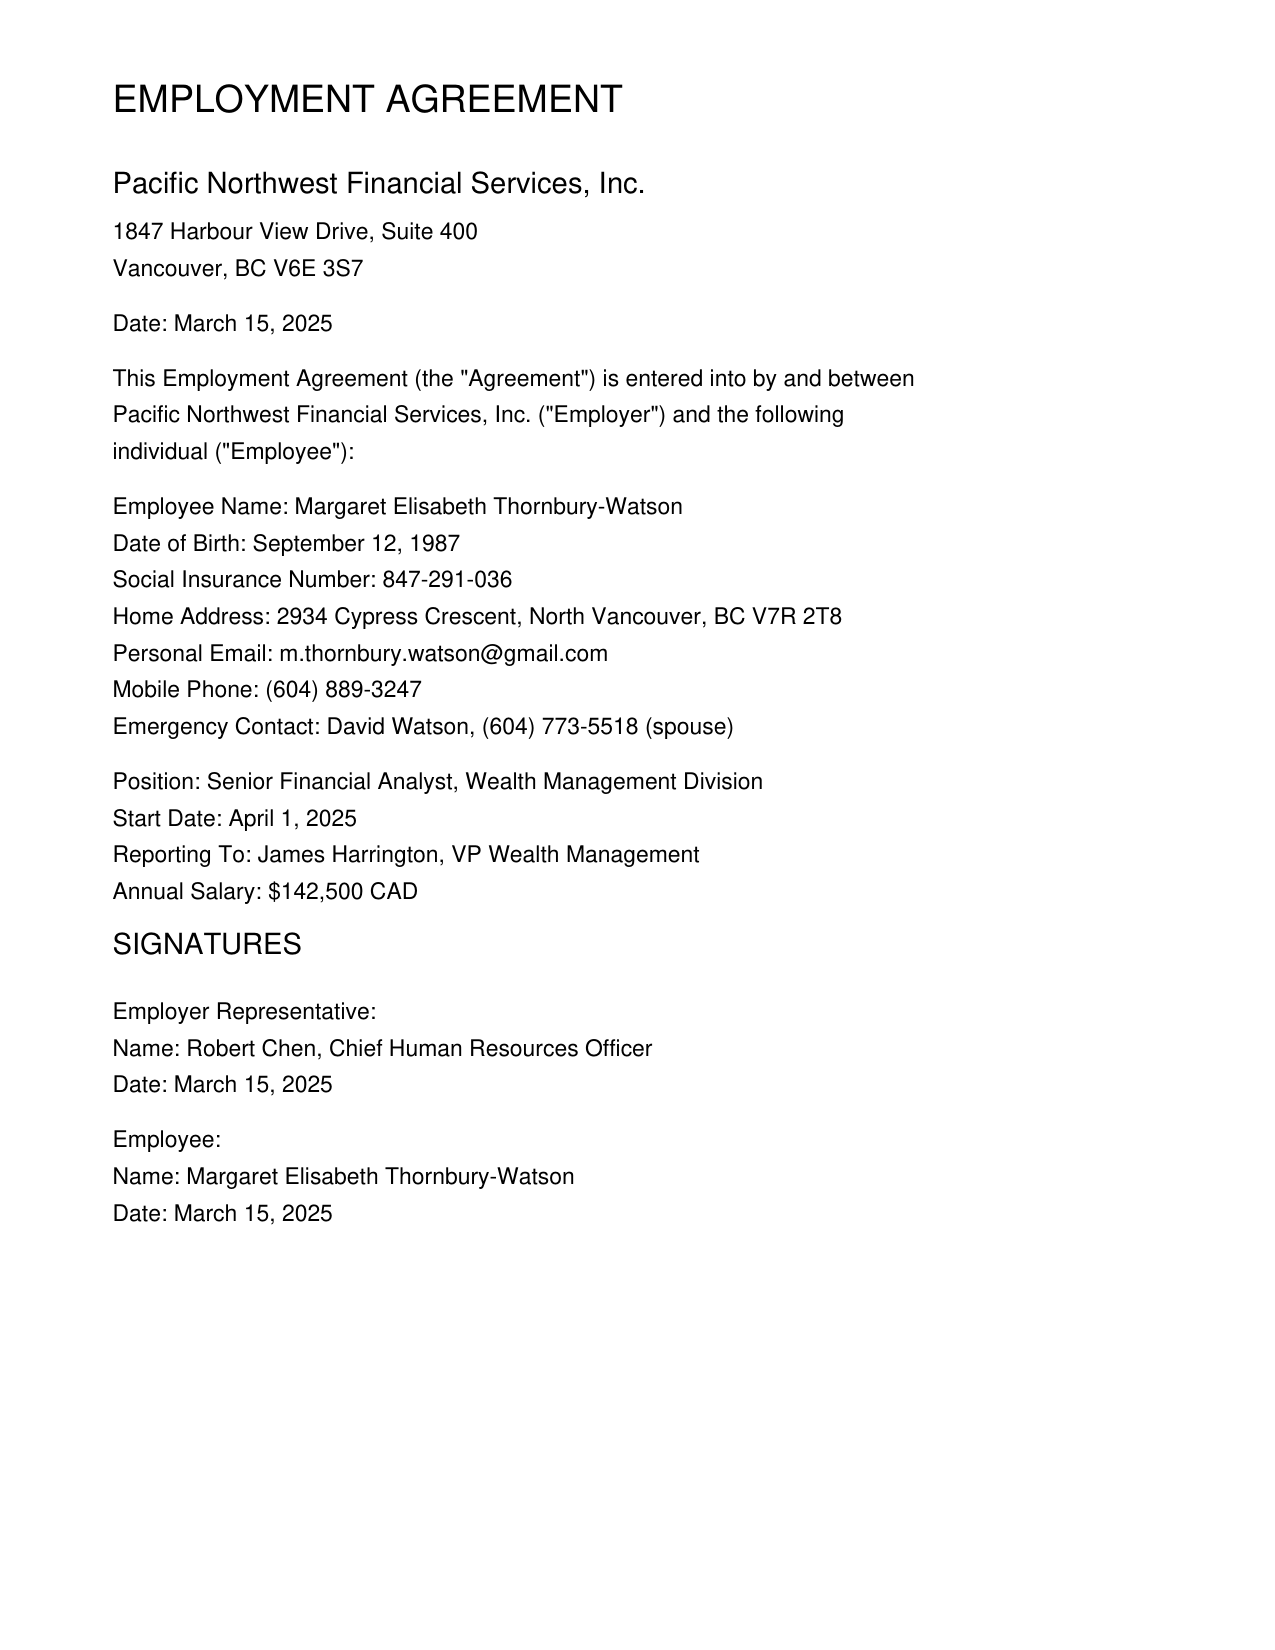

In [4]:
from pathlib import Path

import pymupdf
from IPython.display import Image, display

pdf_path = Path("sample/input/PNFS-Employment-Agreement-2025.pdf").resolve()
documents = [File(path=str(pdf_path))]

with pymupdf.open(str(pdf_path)) as doc:
    total_pages = len(doc)

print(f"Loaded: {pdf_path.name} ({total_pages} pages)")

# Preview page 1
print("\nPage 1 — BEFORE redaction:")
with pymupdf.open(str(pdf_path)) as doc:
    pix = doc[0].get_pixmap(dpi=150)
    display(Image(data=pix.tobytes("png")))

## Step 5: Build and run the RLM

In [5]:
import time

from predict_rlm import PredictRLM

CRITERIA = """
Redact all personally identifiable information (PII), including:

1. **Names** — Full names of individuals (not company or organization names)
2. **Contact info** — Phone numbers, email addresses, fax numbers
3. **Addresses** — Street addresses, P.O. boxes (not city/state/country)
4. **Government IDs** — Social security numbers, tax IDs, passport numbers
5. **Financial info** — Bank account numbers, credit card numbers, routing numbers
6. **Signatures** — Handwritten signatures (redact the bounding area)

Added to this, redact any dates found in the document, in any format.
""".strip()

sig = RedactDocuments.with_instructions(
    RedactDocuments.instructions + "\n\n# Redaction Criteria\n\n" + CRITERIA
)

rlm = PredictRLM(
    sig,
    lm="openai/gpt-5.4",
    sub_lm="openai/gpt-5.1",
    skills=[pdf_skill, redaction_skill],
    max_iterations=30,
    verbose=True,
)

start = time.perf_counter()
prediction = await rlm.acall(documents=documents)
duration = time.perf_counter() - start

redaction_result = prediction.result
mins, secs = divmod(int(duration), 60)
print(f"\nDone in {mins}m {secs}s — {redaction_result.total_redactions} redactions applied")

2026/04/01 11:26:39 INFO dspy.predict.rlm: RLM iteration 1/30
Reasoning: First iteration: explore the input document before attempting extraction/redaction. I should inspect the PDF metadata, page count, and get a quick text sample per page plus render at least one page description so I understand structure. Then I can plan targeted extraction/redaction.
Code:
```repl
import os, json, base64, pymupdf

print("documents:", documents)

pdf_path = documents[0]
doc = pymupdf.open(pdf_path)
print("filename:", os.path.basename(pdf_path))
print("page_count:", len(doc))
print("metadata:", doc.metadata)

# Print concise text samples for each page
for i in range(len(doc)):
    txt = doc[i].get_text("text")
    sample = " ".join(txt.split())[:400]
    print(f"PAGE {i} TEXT SAMPLE:", sample)

# Render first page for visual understanding
pix = doc[0].get_pixmap(dpi=150)
img0 = f"data:image/png;base64,{base64.b64encode(pix.tobytes('png')).decode()}"
desc = await predict(
    "page: dspy.Image -> desc


Done in 1m 32s — 79 redactions applied


## Results

### Before and after

Page 1 — BEFORE redaction:


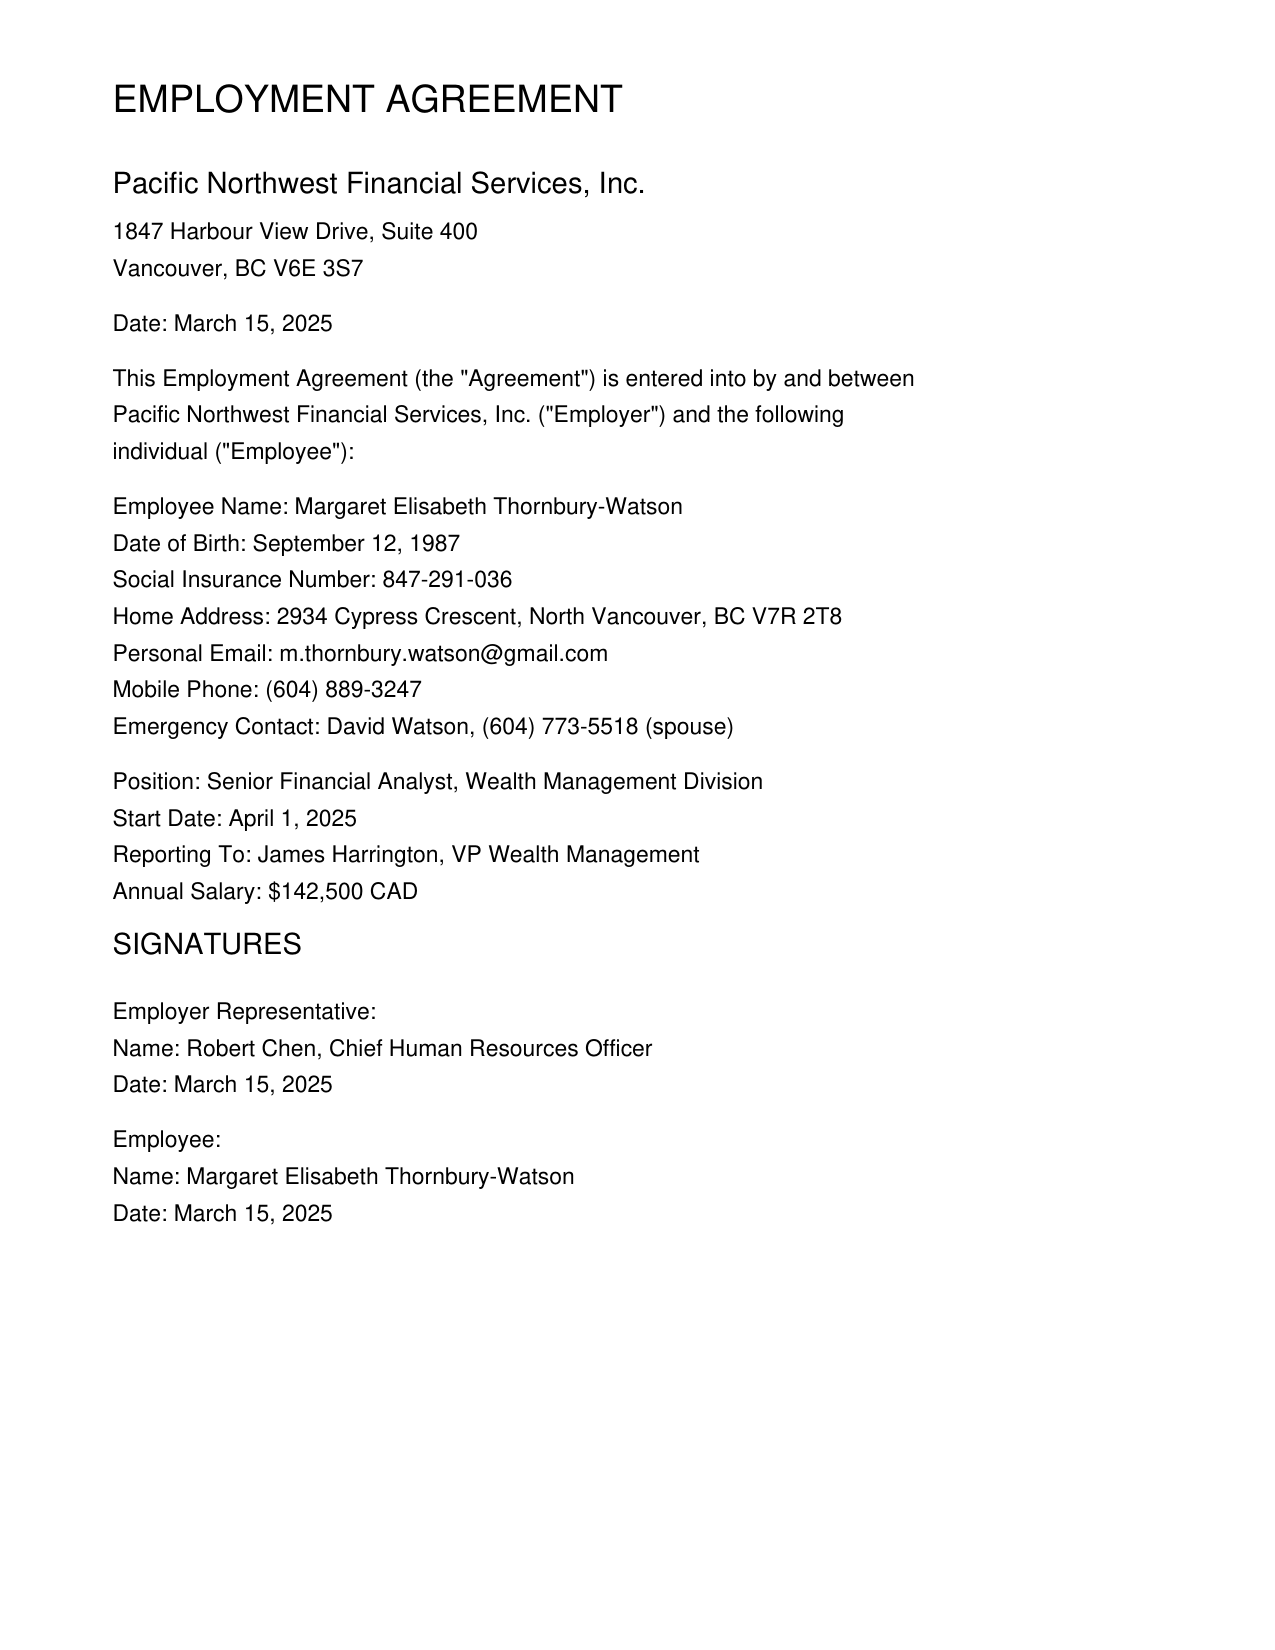


Page 1 — AFTER redaction:


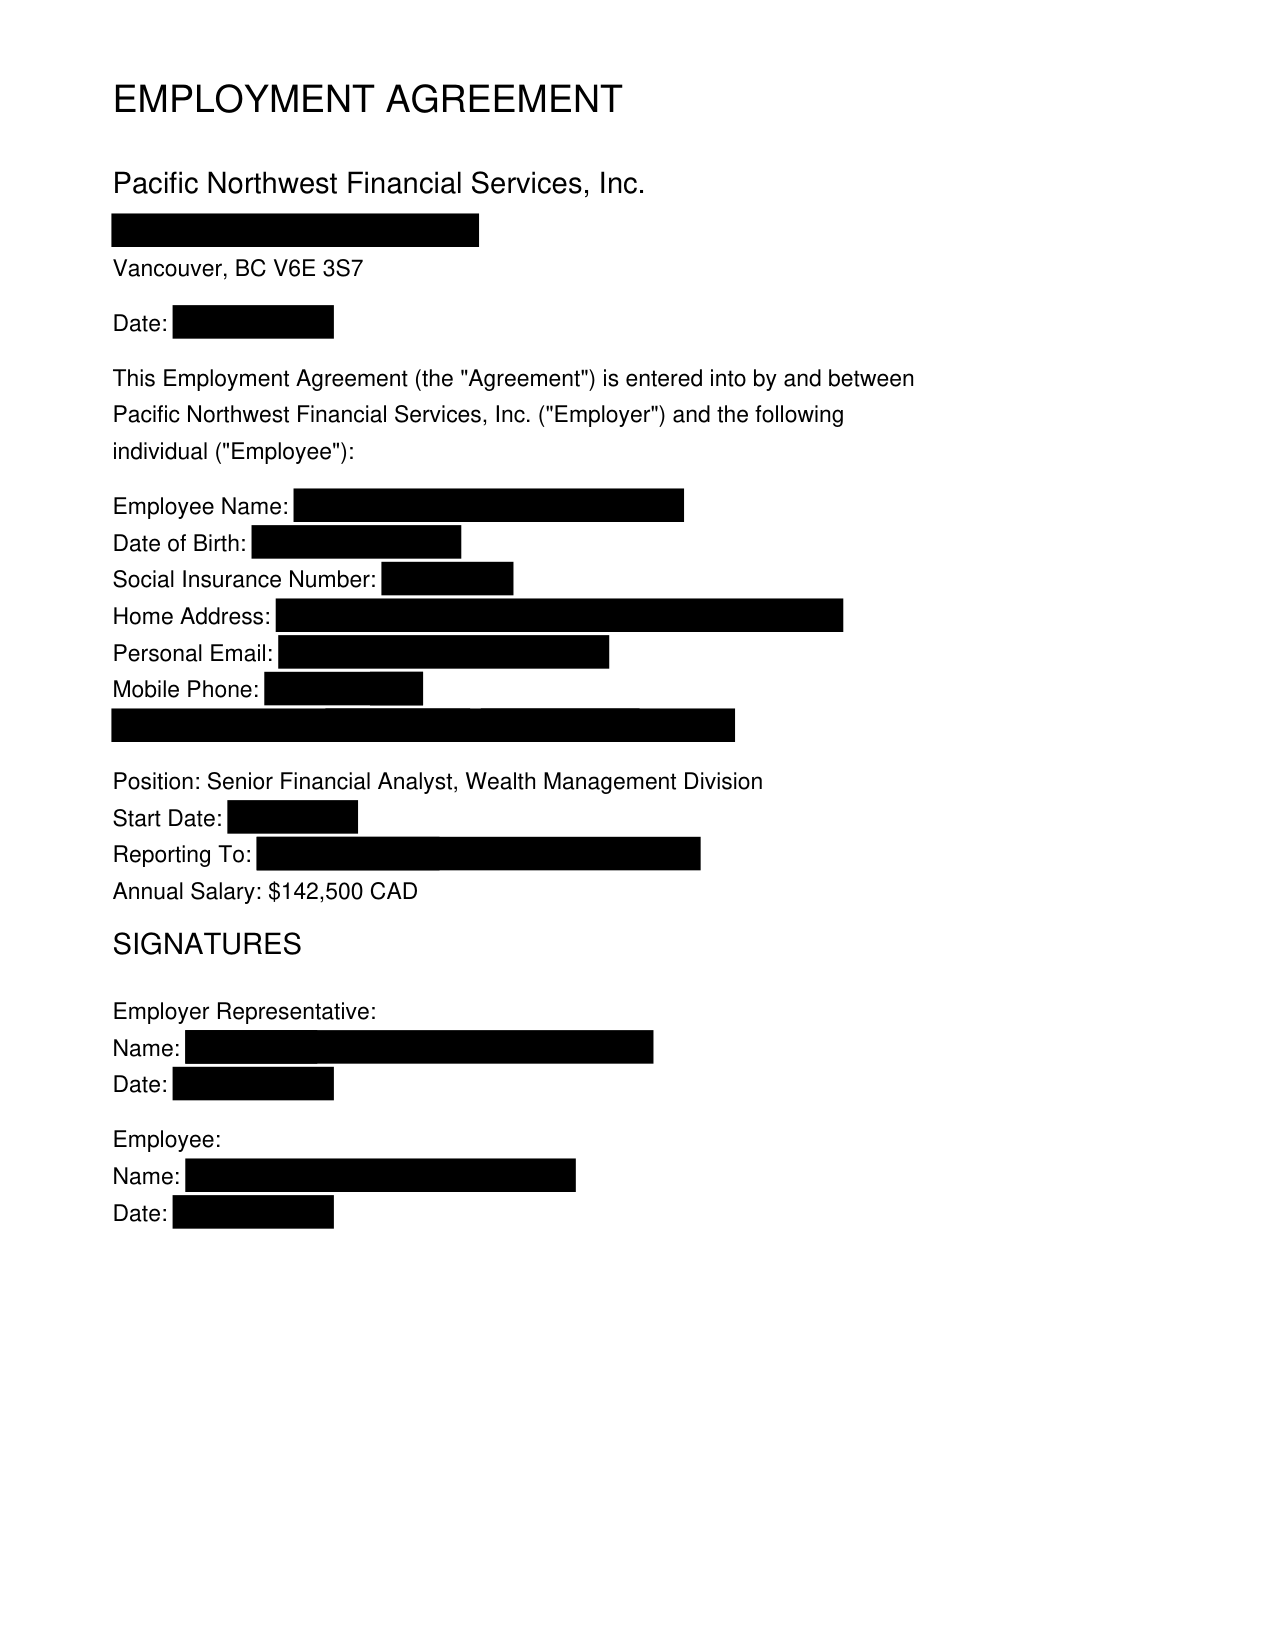

In [6]:
# Page 1 BEFORE (from original file)
print("Page 1 — BEFORE redaction:")
with pymupdf.open(str(pdf_path)) as original:
    pix = original[0].get_pixmap(dpi=150)
    display(Image(data=pix.tobytes("png")))

# Page 1 AFTER (from redacted file in output dir)
print("\nPage 1 — AFTER redaction:")
redacted_files = [Path(f.path) for f in prediction.redacted_documents if f.path]
if redacted_files:
    with pymupdf.open(str(redacted_files[0])) as redacted:
        pix = redacted[0].get_pixmap(dpi=150)
        display(Image(data=pix.tobytes("png")))
else:
    print("No redacted PDF found in output directory")

### Redaction report

In [7]:
print(f"Total redactions: {redaction_result.total_redactions}\n")

print("PER-PAGE SUMMARY")
print("-" * 60)
for ps in redaction_result.page_summaries:
    cats = ", ".join(ps.categories) if ps.categories else "none"
    print(f"  Page {ps.page}: {ps.redaction_count} redaction(s) [{cats}]")

print()
print("REDACTION TARGETS (first 20)")
print("-" * 60)
for t in redaction_result.targets[:20]:
    print(f'  Page {t.page} [{t.category}]: "{t.text}"')

Total redactions: 79

PER-PAGE SUMMARY
------------------------------------------------------------
  Page 0: 16 redaction(s) [address, date, email, government_id, person_name, phone_number]
  Page 1: 14 redaction(s) [address, date, financial_info, government_id, person_name]
  Page 2: 17 redaction(s) [address, date, email, government_id, person_name, phone_number]
  Page 3: 8 redaction(s) [email, financial_info, government_id, person_name, phone_number]
  Page 4: 20 redaction(s) [address, date, email, financial_info, government_id, person_name, phone_number]
  Page 5: 4 redaction(s) [address, date, government_id]

REDACTION TARGETS (first 20)
------------------------------------------------------------
  Page 0 [email]: "m.thornbury.watson@gmail.com"
  Page 0 [phone_number]: "(604) 889-3247"
  Page 0 [phone_number]: "(604) 773-5518"
  Page 0 [date]: "March 15, 2025"
  Page 0 [date]: "September 12, 1987"
  Page 0 [date]: "April 1, 2025"
  Page 0 [government_id]: "847-291-036"
  Page 0 

### Save redacted PDF and run stats

In [8]:
import shutil

# Copy redacted PDFs to output/
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
if redacted_files:
    for f in redacted_files:
        dest = output_dir / f.name
        shutil.copy2(f, dest)
        print(f"Saved: {dest}")

# Run stats
lm_history = list(rlm._lm.history)
sub_lm_history = list(rlm._sub_lm.history)

lm_cost = sum(e.get("cost", 0) or 0 for e in lm_history)
lm_input = sum(e.get("usage", {}).get("prompt_tokens", 0) or 0 for e in lm_history)
lm_output = sum(e.get("usage", {}).get("completion_tokens", 0) or 0 for e in lm_history)

sub_lm_cost = sum(e.get("cost", 0) or 0 for e in sub_lm_history)
sub_lm_input = sum(e.get("usage", {}).get("prompt_tokens", 0) or 0 for e in sub_lm_history)
sub_lm_output = sum(e.get("usage", {}).get("completion_tokens", 0) or 0 for e in sub_lm_history)

total_cost = lm_cost + sub_lm_cost

print(f"\nMain LM ({len(lm_history)} calls):")
print(f"  Input:  {lm_input:,} tokens")
print(f"  Output: {lm_output:,} tokens")
print(f"  Cost:   ${lm_cost:.4f}")
print()
print(f"Sub-LM ({len(sub_lm_history)} calls):")
print(f"  Input:  {sub_lm_input:,} tokens")
print(f"  Output: {sub_lm_output:,} tokens")
print(f"  Cost:   ${sub_lm_cost:.4f}")
print()
print(f"Total:     ${total_cost:.4f} ({total_pages} pages, ${total_cost / max(total_pages, 1):.4f}/page)")
print(f"Duration:  {mins}m {secs}s")

Saved: output/PNFS-Employment-Agreement-2025.pdf

Main LM (5 calls):
  Input:  38,457 tokens
  Output: 4,848 tokens
  Cost:   $0.1049

Sub-LM (13 calls):
  Input:  11,760 tokens
  Output: 2,558 tokens
  Cost:   $0.0403

Total:     $0.1452 (6 pages, $0.0242/page)
Duration:  1m 32s
